# Machine Learning Pipelines: End-to-End Project
### Using the Titanic Dataset

This notebook covers:
- Data Loading & Exploration
- Data Preprocessing
- Building ML Pipelines
- Model Evaluation
- Hyperparameter Tuning
- Advanced Pipeline Techniques
- Model Interpretation

In [1]:
# Install required libraries (run once if needed)
# !pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    RandomizedSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, PolynomialFeatures, FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.inspection import PartialDependenceDisplay

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## Section 1: Data Loading and Exploration

In [3]:
# Load Titanic dataset from seaborn (built-in, no download needed)
df = sns.load_dataset('titanic')
print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')

Dataset loaded successfully!
Shape: (891, 15)


In [4]:
# Display the first 10 rows
print('=== First 10 Rows ===')
df.head(10)

=== First 10 Rows ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [5]:
# Dataset Information
print('=== Dataset Information ===')
print(f'Number of Rows    : {df.shape[0]}')
print(f'Number of Columns : {df.shape[1]}')
print()
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- Missing Values ---')
print(df.isnull().sum())

=== Dataset Information ===
Number of Rows    : 891
Number of Columns : 15

--- Data Types ---
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

--- Missing Values ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [6]:
# Identify numerical and categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('=== Feature Types ===')
print(f'Numerical Features  ({len(numerical_features)}): {numerical_features}')
print(f'Categorical Features ({len(categorical_features)}): {categorical_features}')

=== Feature Types ===
Numerical Features  (6): ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical Features (9): ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


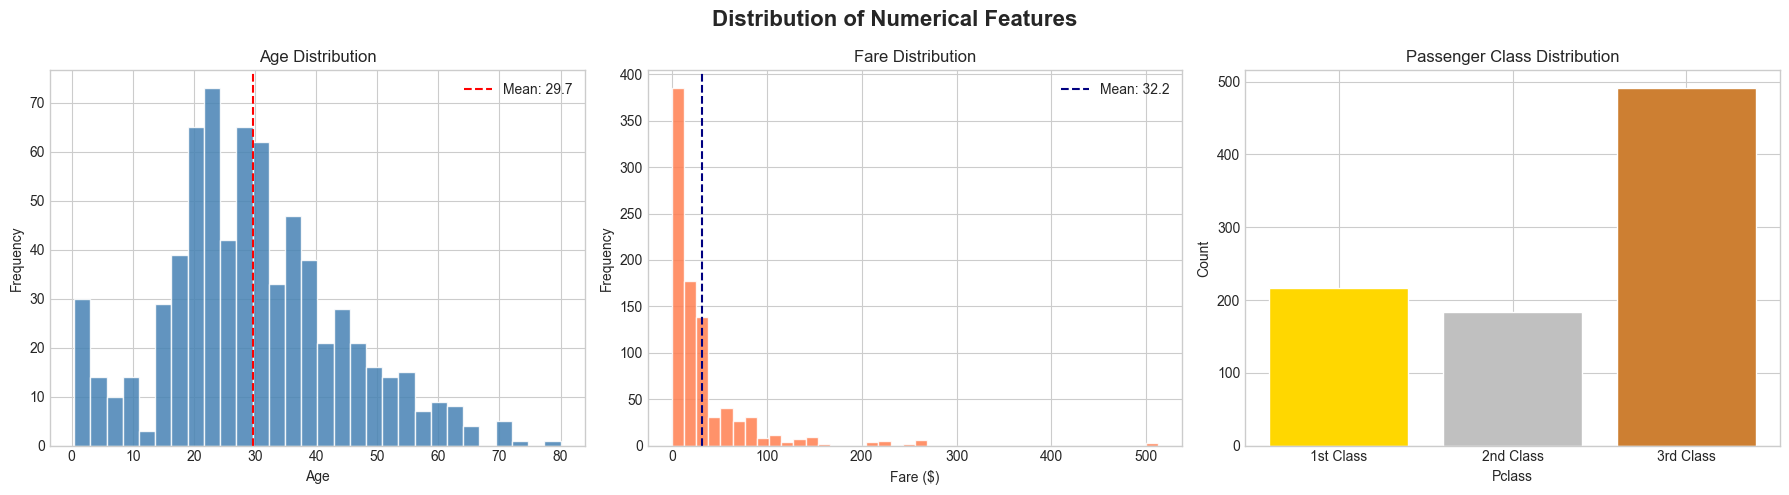

Distribution plots saved.


In [7]:
# Visualize distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

# Age distribution
axes[0].hist(df['age'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
axes[0].legend()

# Fare distribution
axes[1].hist(df['fare'].dropna(), bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare ($)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['fare'].mean(), color='navy', linestyle='--', label=f'Mean: {df["fare"].mean():.1f}')
axes[1].legend()

# Pclass distribution
pclass_counts = df['pclass'].value_counts().sort_index()
axes[2].bar(pclass_counts.index, pclass_counts.values, color=['gold', 'silver', '#cd7f32'], edgecolor='white')
axes[2].set_title('Passenger Class Distribution')
axes[2].set_xlabel('Pclass')
axes[2].set_ylabel('Count')
axes[2].set_xticks([1, 2, 3])
axes[2].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Distribution plots saved.')

---
## Section 2: Data Preprocessing

In [8]:
# Prepare features and target
# Select useful columns
features_to_use = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target_col = 'survived'

X = df[features_to_use].copy()
y = df[target_col].copy()

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Survival rate: {y.mean():.2%}')

Feature matrix shape: (891, 7)
Target shape: (891,)
Survival rate: 38.38%


In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('=== Train-Test Split ===')
print(f'Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.0%})')
print(f'Testing set    : {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.0%})')
print(f'Train survival : {y_train.mean():.2%}')
print(f'Test survival  : {y_test.mean():.2%}')

=== Train-Test Split ===
Training set   : 712 samples (80%)
Testing set    : 179 samples (20%)
Train survival : 38.34%
Test survival  : 38.55%


In [10]:
# Define numeric and categorical columns
numeric_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']
categorical_cols = ['sex', 'embarked']

# Numeric pipeline: Impute missing values + Scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute + OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer applies different preprocessing to different columns
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Demonstrate the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('=== Preprocessing Results ===')
print(f'Original feature count   : {X_train.shape[1]}')
print(f'Processed feature count  : {X_train_processed.shape[1]}')
print(f'Train processed shape    : {X_train_processed.shape}')
print(f'Missing values remaining : {np.isnan(X_train_processed).sum()}')

=== Preprocessing Results ===
Original feature count   : 7
Processed feature count  : 10
Train processed shape    : (712, 10)
Missing values remaining : 0


---
## Section 3: Building Machine Learning Pipelines

In [11]:
# Pipeline 1: Basic Pipeline — StandardScaler + LogisticRegression
# Note: Uses only numeric columns for simplicity here
basic_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=500))
])

X_num_train = X_train[numeric_cols]
X_num_test = X_test[numeric_cols]

basic_pipeline.fit(X_num_train, y_train)
basic_acc = basic_pipeline.score(X_num_test, y_test)
print(f'Pipeline 1 (Basic): Accuracy = {basic_acc:.4f}')
print('Steps:', [step[0] for step in basic_pipeline.steps])

Pipeline 1 (Basic): Accuracy = 0.6760
Steps: ['imputer', 'scaler', 'classifier']


In [12]:
# Pipeline 2: Full Pipeline with ColumnTransformer Preprocessing
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=500))
])

full_pipeline.fit(X_train, y_train)
full_acc = full_pipeline.score(X_test, y_test)
print(f'Pipeline 2 (Full Preprocessing): Accuracy = {full_acc:.4f}')
print('Steps:', [step[0] for step in full_pipeline.steps])

Pipeline 2 (Full Preprocessing): Accuracy = 0.8045
Steps: ['preprocessor', 'classifier']


In [13]:
# Pipeline 3: With Feature Selection using SelectKBest
selectk_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_classif, k=6)),
    ('classifier', LogisticRegression(random_state=42, max_iter=500))
])

selectk_pipeline.fit(X_train, y_train)
selectk_acc = selectk_pipeline.score(X_test, y_test)
print(f'Pipeline 3 (SelectKBest k=6): Accuracy = {selectk_acc:.4f}')
print('Steps:', [step[0] for step in selectk_pipeline.steps])

Pipeline 3 (SelectKBest k=6): Accuracy = 0.7654
Steps: ['preprocessor', 'selector', 'classifier']


In [14]:
# Pipeline 4: With PolynomialFeatures
poly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, C=0.1))
])

poly_pipeline.fit(X_train, y_train)
poly_acc = poly_pipeline.score(X_test, y_test)
print(f'Pipeline 4 (PolynomialFeatures): Accuracy = {poly_acc:.4f}')
print('Steps:', [step[0] for step in poly_pipeline.steps])

Pipeline 4 (PolynomialFeatures): Accuracy = 0.8156
Steps: ['preprocessor', 'poly', 'classifier']


In [15]:
# Pipeline 5: Dimensionality Reduction with PCA
pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=500))
])

pca_pipeline.fit(X_train, y_train)
pca_acc = pca_pipeline.score(X_test, y_test)

# PCA explained variance
explained_var = pca_pipeline.named_steps['pca'].explained_variance_ratio_
print(f'Pipeline 5 (PCA): Accuracy = {pca_acc:.4f}')
print(f'Explained variance per component: {[f"{v:.2%}" for v in explained_var]}')
print(f'Total variance explained: {sum(explained_var):.2%}')

Pipeline 5 (PCA): Accuracy = 0.8101
Explained variance per component: ['29.57%', '27.44%', '12.89%', '10.56%', '6.71%']
Total variance explained: 87.17%


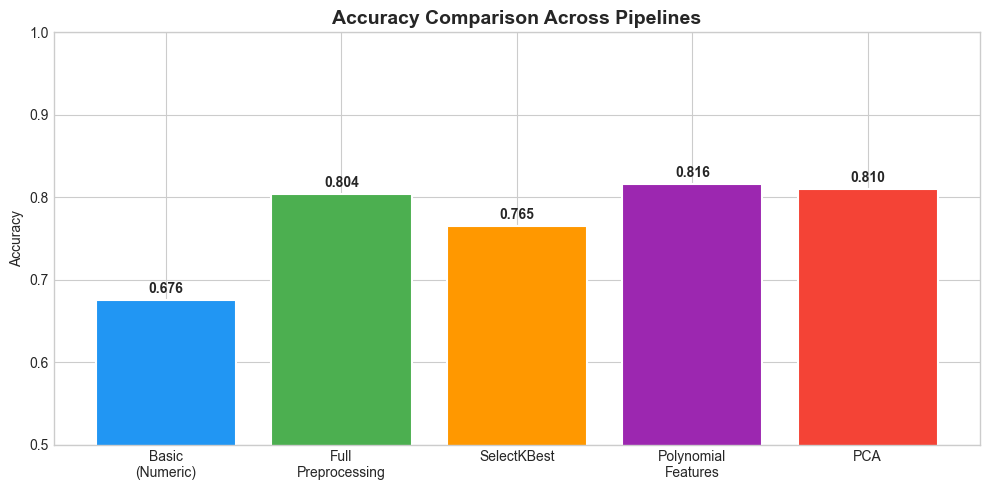

In [16]:
# Summary bar chart of all pipeline accuracies
pipeline_names = ['Basic\n(Numeric)', 'Full\nPreprocessing', 'SelectKBest', 'Polynomial\nFeatures', 'PCA']
accuracies = [basic_acc, full_acc, selectk_acc, poly_acc, pca_acc]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(pipeline_names, accuracies, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylim(0.5, 1.0)
ax.set_title('Accuracy Comparison Across Pipelines', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Model Evaluation

In [17]:
# Train-test split evaluation
y_pred = full_pipeline.predict(X_test)

print('=== Model Evaluation (Train-Test Split) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

=== Model Evaluation (Train-Test Split) ===
Accuracy: 0.8045

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



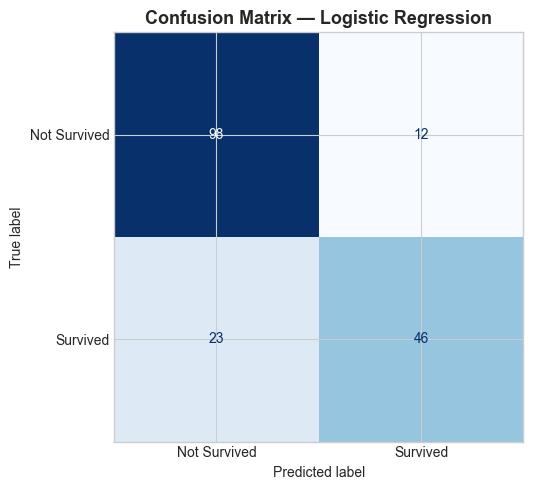

In [18]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Cross-Validation
cv_scores = cross_val_score(full_pipeline, X, y, cv=10, scoring='accuracy')

print('=== Cross-Validation (10-Fold) ===')
print(f'CV Scores     : {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean Accuracy : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')
print()
print('=== Comparison: Train-Test vs Cross-Validation ===')
print(f'Train-Test Accuracy : {full_acc:.4f}')
print(f'CV Mean Accuracy    : {cv_scores.mean():.4f}')
print(f'Difference          : {abs(full_acc - cv_scores.mean()):.4f}')

=== Cross-Validation (10-Fold) ===
CV Scores     : ['0.7889', '0.7978', '0.7416', '0.8090', '0.7865', '0.7640', '0.7865', '0.7865', '0.8090', '0.8315']
Mean Accuracy : 0.7901 (+/- 0.0471)

=== Comparison: Train-Test vs Cross-Validation ===
Train-Test Accuracy : 0.8045
CV Mean Accuracy    : 0.7901
Difference          : 0.0143


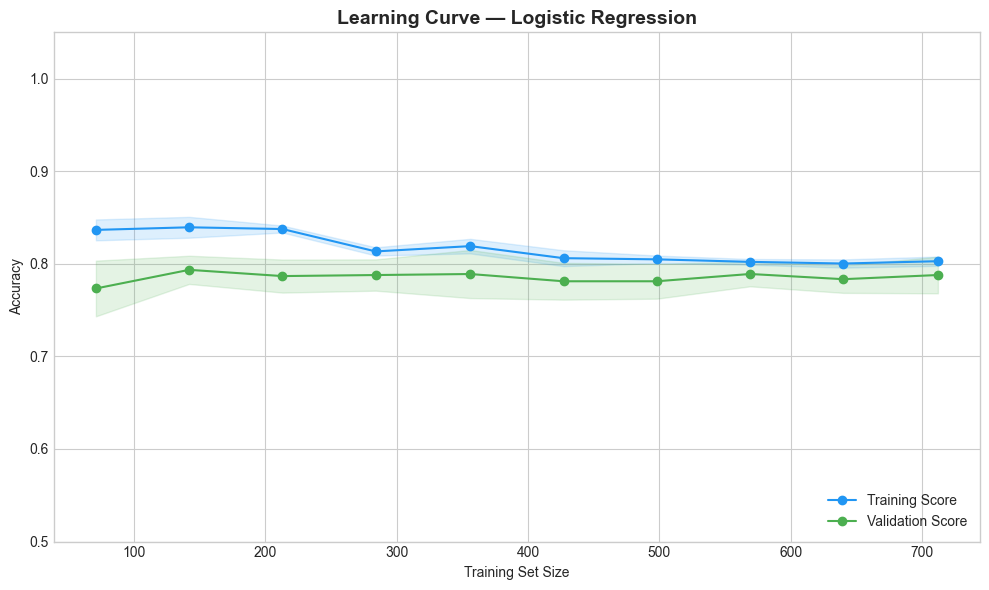

In [20]:
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    full_pipeline, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')
ax.plot(train_sizes, val_mean, 'o-', color='#4CAF50', label='Validation Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#4CAF50')

ax.set_title('Learning Curve — Logistic Regression', fontsize=14, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5: Hyperparameter Tuning

In [21]:
# GridSearchCV
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    full_pipeline, param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print('=== GridSearchCV Results ===')
print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV Score   : {grid_search.best_score_:.4f}')
print(f'Test Accuracy   : {grid_search.score(X_test, y_test):.4f}')

=== GridSearchCV Results ===
Best Parameters : {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV Score   : 0.8020
Test Accuracy   : 0.7933


In [22]:
# RandomizedSearchCV — with RandomForest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_dist = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [None, 3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    rf_pipeline, param_dist,
    n_iter=30, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=0
)
random_search.fit(X_train, y_train)

print('=== RandomizedSearchCV Results (RandomForest) ===')
print(f'Best Parameters : {random_search.best_params_}')
print(f'Best CV Score   : {random_search.best_score_:.4f}')
print(f'Test Accuracy   : {random_search.score(X_test, y_test):.4f}')

=== RandomizedSearchCV Results (RandomForest) ===
Best Parameters : {'classifier__n_estimators': 50, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': None}
Best CV Score   : 0.8259
Test Accuracy   : 0.8045


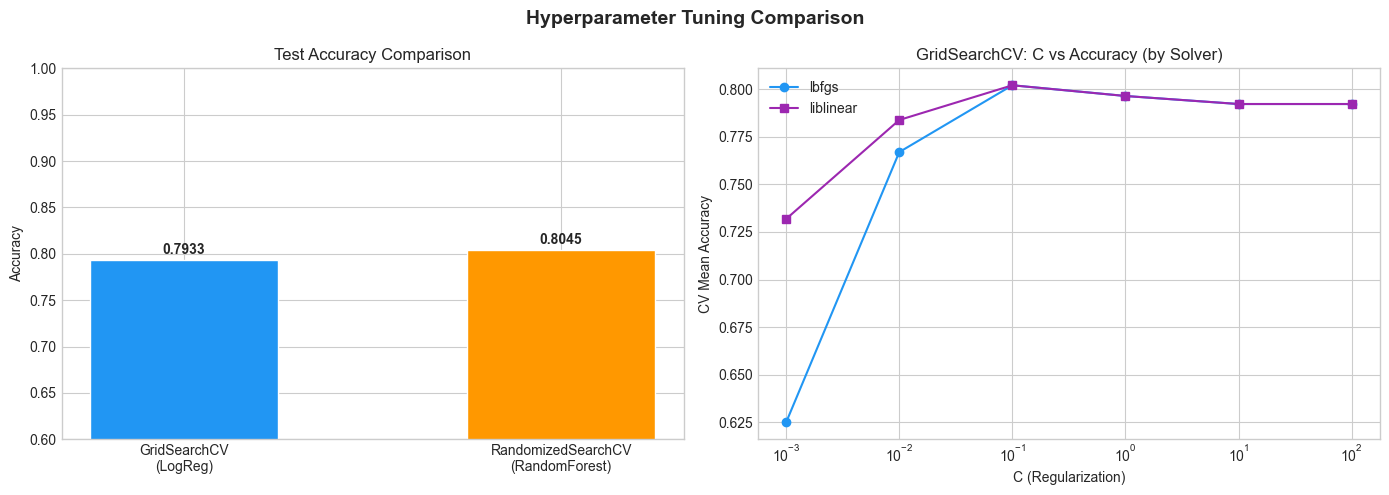

In [23]:
# Compare GridSearchCV vs RandomizedSearchCV
grid_test_acc = grid_search.score(X_test, y_test)
rand_test_acc = random_search.score(X_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hyperparameter Tuning Comparison', fontsize=14, fontweight='bold')

# Comparison bar
methods = ['GridSearchCV\n(LogReg)', 'RandomizedSearchCV\n(RandomForest)']
scores = [grid_test_acc, rand_test_acc]
bars = axes[0].bar(methods, scores, color=['#2196F3', '#FF9800'], edgecolor='white', width=0.5)
axes[0].set_ylim(0.6, 1.0)
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
for bar, sc in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{sc:.4f}', ha='center', va='bottom', fontweight='bold')

# Grid search CV scores heatmap-like view
grid_results = pd.DataFrame(grid_search.cv_results_)
pivot = grid_results[grid_results['param_classifier__solver'] == 'lbfgs'].pivot_table(
    values='mean_test_score',
    index='param_classifier__C'
)
axes[1].plot(grid_results[grid_results['param_classifier__solver'] == 'lbfgs']['param_classifier__C'],
             grid_results[grid_results['param_classifier__solver'] == 'lbfgs']['mean_test_score'],
             'o-', color='#2196F3', label='lbfgs')
axes[1].plot(grid_results[grid_results['param_classifier__solver'] == 'liblinear']['param_classifier__C'],
             grid_results[grid_results['param_classifier__solver'] == 'liblinear']['mean_test_score'],
             's-', color='#9C27B0', label='liblinear')
axes[1].set_xscale('log')
axes[1].set_title('GridSearchCV: C vs Accuracy (by Solver)')
axes[1].set_xlabel('C (Regularization)')
axes[1].set_ylabel('CV Mean Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6: Advanced Pipeline Techniques

In [24]:
# Custom Transformer using BaseEstimator + TransformerMixin
class FamilySizeTransformer(BaseEstimator, TransformerMixin):
    """Custom transformer: creates FamilySize = SibSp + Parch + 1"""
    
    def __init__(self, drop_original=True):
        self.drop_original = drop_original
    
    def fit(self, X, y=None):
        return self  # nothing to learn
    
    def transform(self, X):
        X = X.copy()
        if hasattr(X, 'iloc'):  # DataFrame
            X['family_size'] = X['sibsp'] + X['parch'] + 1
            X['is_alone'] = (X['family_size'] == 1).astype(int)
            if self.drop_original:
                X = X.drop(columns=['sibsp', 'parch'])
        return X

# Test the custom transformer
fst = FamilySizeTransformer(drop_original=True)
X_custom = fst.fit_transform(X_train)
print('=== Custom Transformer: FamilySizeTransformer ===')
print(f'Original columns : {list(X_train.columns)}')
print(f'New columns      : {list(X_custom.columns)}')
print(X_custom[['family_size', 'is_alone']].head())

=== Custom Transformer: FamilySizeTransformer ===
Original columns : ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
New columns      : ['pclass', 'sex', 'age', 'fare', 'embarked', 'family_size', 'is_alone']
     family_size  is_alone
692            1         1
481            1         1
527            1         1
855            2         0
801            3         0


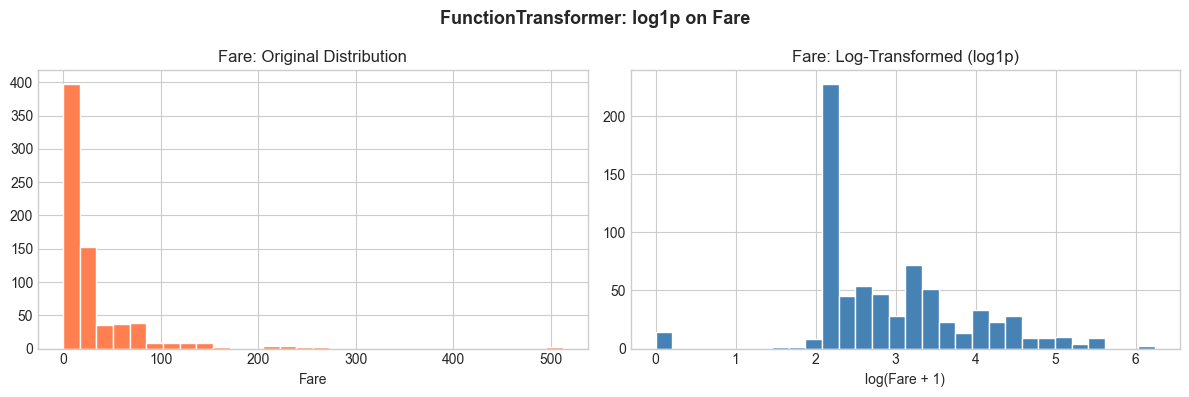

FunctionTransformer applied: Skewness reduced significantly


In [25]:
# FunctionTransformer — apply log1p to 'fare'
log_transformer = FunctionTransformer(np.log1p, validate=True)

fare_train = X_train[['fare']].fillna(X_train['fare'].median()).values
fare_log = log_transformer.fit_transform(fare_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fare_train, bins=30, color='coral', edgecolor='white')
axes[0].set_title('Fare: Original Distribution')
axes[0].set_xlabel('Fare')

axes[1].hist(fare_log, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Fare: Log-Transformed (log1p)')
axes[1].set_xlabel('log(Fare + 1)')

plt.suptitle('FunctionTransformer: log1p on Fare', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('log_transform.png', dpi=150, bbox_inches='tight')
plt.show()
print('FunctionTransformer applied: Skewness reduced significantly')

In [26]:
# FeatureUnion — combine PCA and SelectKBest features
union = FeatureUnion(transformer_list=[
    ('pca_features', PCA(n_components=3)),
    ('kbest_features', SelectKBest(f_classif, k=3))
])

feature_union_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_union', union),
    ('classifier', LogisticRegression(random_state=42, max_iter=500))
])

feature_union_pipeline.fit(X_train, y_train)
fu_acc = feature_union_pipeline.score(X_test, y_test)
print(f'=== FeatureUnion Pipeline ===')
print(f'FeatureUnion (PCA + SelectKBest): Accuracy = {fu_acc:.4f}')
print('Combined features: 3 PCA components + 3 SelectKBest = 6 total')

=== FeatureUnion Pipeline ===
FeatureUnion (PCA + SelectKBest): Accuracy = 0.8045
Combined features: 3 PCA components + 3 SelectKBest = 6 total


In [27]:
# Nested Pipeline — Advanced nested structure
inner_numeric = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

inner_categorical = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

inner_preprocessor = ColumnTransformer([
    ('num', inner_numeric, numeric_cols),
    ('cat', inner_categorical, categorical_cols)
])

nested_pipeline = Pipeline([
    ('preprocessing', inner_preprocessor),
    ('dim_reduction', PCA(n_components=6)),
    ('feature_selection', SelectKBest(f_classif, k=5)),
    ('model', GradientBoostingClassifier(random_state=42, n_estimators=100))
])

nested_pipeline.fit(X_train, y_train)
nested_acc = nested_pipeline.score(X_test, y_test)
print('=== Nested Pipeline (Preprocessing → PCA → SelectKBest → GBM) ===')
print(f'Accuracy: {nested_acc:.4f}')
print('Pipeline steps:', [s[0] for s in nested_pipeline.steps])

=== Nested Pipeline (Preprocessing → PCA → SelectKBest → GBM) ===
Accuracy: 0.8045
Pipeline steps: ['preprocessing', 'dim_reduction', 'feature_selection', 'model']


---
## Section 7: Model Interpretation

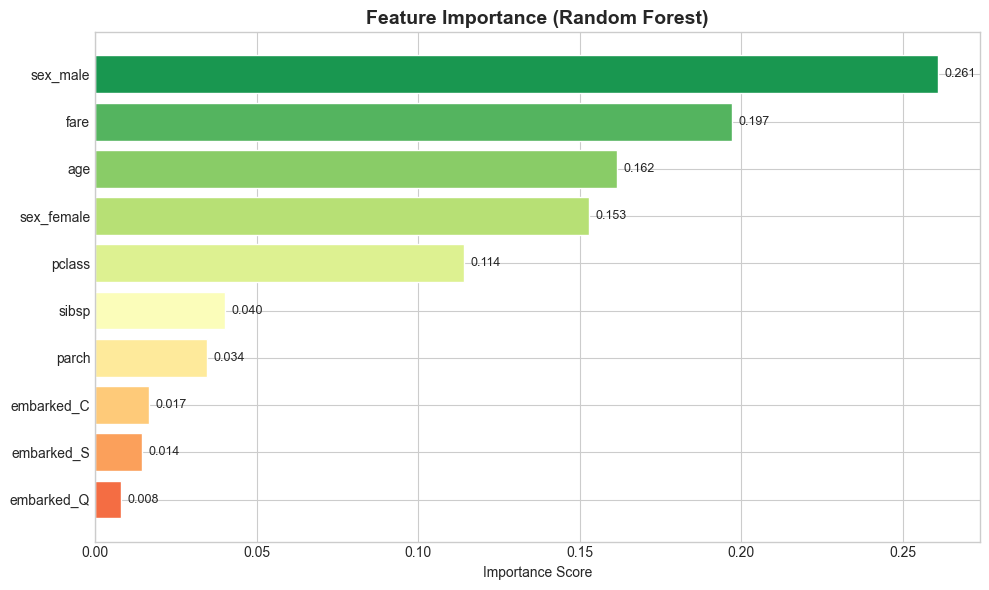

In [28]:
# Feature Importance from Random Forest
best_rf = random_search.best_estimator_

# Get feature names after preprocessing
ohe_features = best_rf.named_steps['preprocessor'].named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(ohe_features)

importances = best_rf.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feature_importance_df)))
bars = ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'],
               color=colors_fi, edgecolor='white')
ax.set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

for bar, val in zip(bars, feature_importance_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

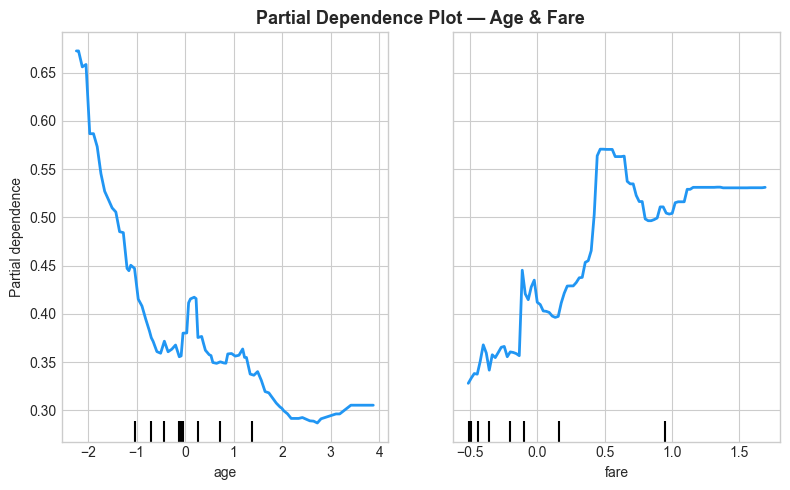

In [29]:
# Partial Dependence Plot (PDP)
# Train a standalone RF on preprocessed data for PDP
X_train_prep = best_rf.named_steps['preprocessor'].transform(X_train)
X_test_prep = best_rf.named_steps['preprocessor'].transform(X_test)

rf_model = best_rf.named_steps['classifier']

fig, ax = plt.subplots(figsize=(8, 5))
# Feature 0 = age, Feature 1 = fare (after preprocessing)
PartialDependenceDisplay.from_estimator(
    rf_model, X_train_prep, features=[0, 1],
    feature_names=all_feature_names,
    ax=ax, line_kw={'color': '#2196F3', 'lw': 2}
)
ax.set_title('Partial Dependence Plot — Age & Fare', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pdp.png', dpi=150, bbox_inches='tight')
plt.show()

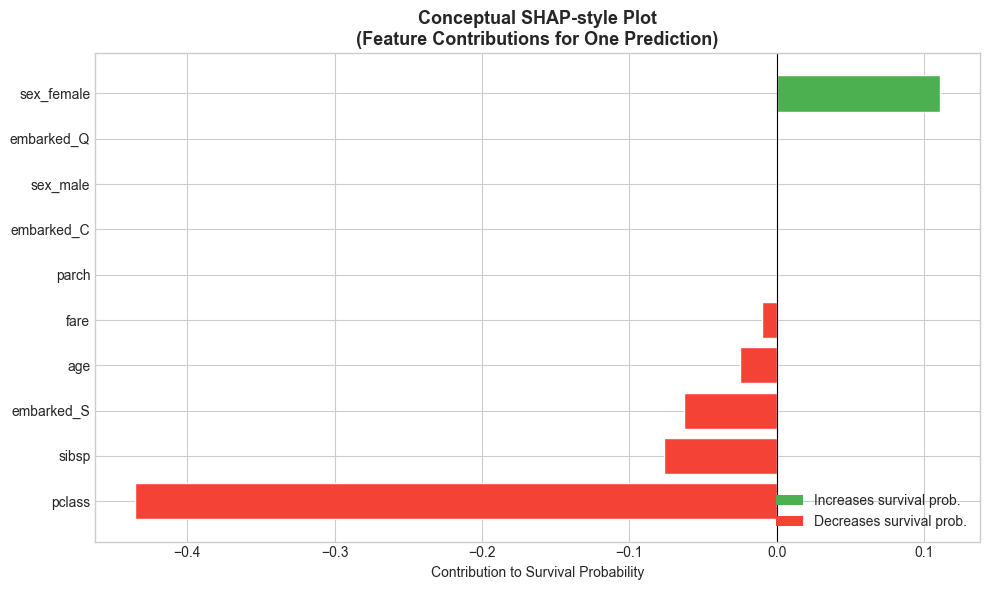

In [30]:
# Conceptual SHAP-style plot (manual approximation using feature importances)
# This shows per-feature contribution direction for a sample prediction

sample_idx = 5
sample = X_test_prep[sample_idx:sample_idx+1]
base_prob = rf_model.predict_proba(X_test_prep).mean(axis=0)[1]

# Approximate SHAP values by measuring impact of zeroing each feature
shap_approx = []
for i in range(X_test_prep.shape[1]):
    X_zeroed = sample.copy()
    X_zeroed[0, i] = 0
    prob_zeroed = rf_model.predict_proba(X_zeroed)[0][1]
    contribution = rf_model.predict_proba(sample)[0][1] - prob_zeroed
    shap_approx.append(contribution)

shap_df = pd.DataFrame({'Feature': all_feature_names, 'Contribution': shap_approx})
shap_df = shap_df.sort_values('Contribution')

fig, ax = plt.subplots(figsize=(10, 6))
colors_shap = ['#F44336' if v < 0 else '#4CAF50' for v in shap_df['Contribution']]
ax.barh(shap_df['Feature'], shap_df['Contribution'], color=colors_shap, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Conceptual SHAP-style Plot\n(Feature Contributions for One Prediction)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Contribution to Survival Probability')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Increases survival prob.'),
                   Patch(facecolor='#F44336', label='Decreases survival prob.')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('shap_style.png', dpi=150, bbox_inches='tight')
plt.show()

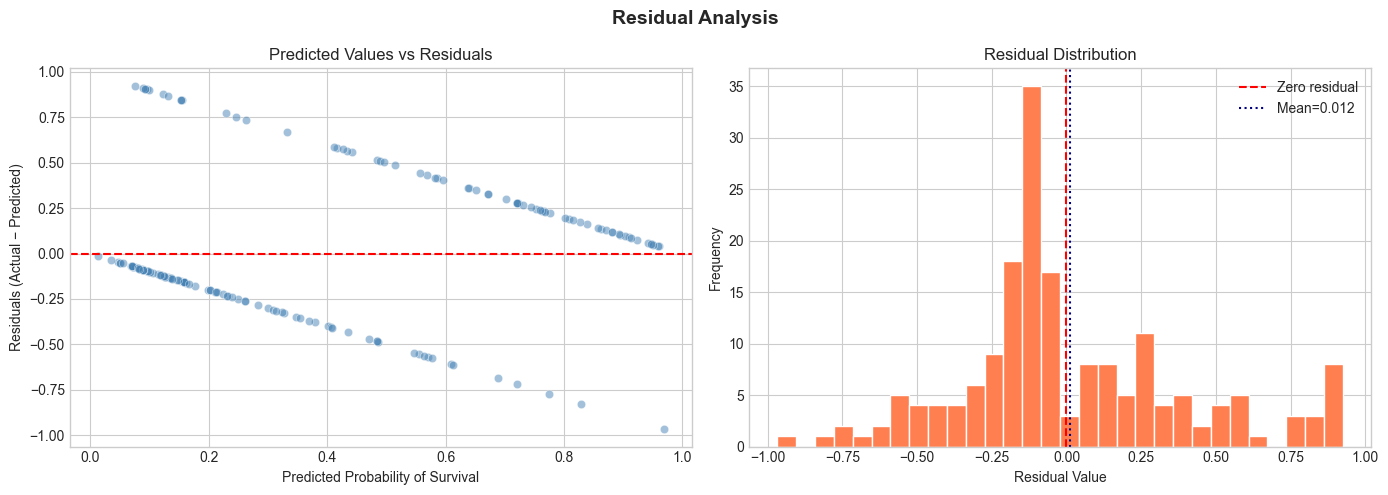

Mean residual   : 0.0116
Std of residuals: 0.3804


In [31]:
# Residual Analysis — predicted probability vs residuals
y_prob = full_pipeline.predict_proba(X_test)[:, 1]
residuals = y_test.values - y_prob

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analysis', fontsize=14, fontweight='bold')

# Predicted vs Residuals scatter
axes[0].scatter(y_prob, residuals, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Probability of Survival')
axes[0].set_ylabel('Residuals (Actual − Predicted)')
axes[0].set_title('Predicted Values vs Residuals')

# Residual distribution
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero residual')
axes[1].axvline(residuals.mean(), color='navy', linestyle=':', linewidth=1.5, label=f'Mean={residuals.mean():.3f}')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean residual   : {residuals.mean():.4f}')
print(f'Std of residuals: {residuals.std():.4f}')

In [32]:
# Final Summary Table
print('=' * 55)
print('         FINAL MODEL ACCURACY SUMMARY')
print('=' * 55)
results = {
    'Basic Pipeline (Numeric Only)': basic_acc,
    'Full Pipeline (All Features)': full_acc,
    'SelectKBest Pipeline': selectk_acc,
    'PolynomialFeatures Pipeline': poly_acc,
    'PCA Pipeline': pca_acc,
    'FeatureUnion Pipeline': fu_acc,
    'Nested Pipeline (GBM)': nested_acc,
    'GridSearchCV (Best LogReg)': grid_test_acc,
    'RandomizedSearch (Best RF)': rand_test_acc,
    '10-Fold CV Mean': cv_scores.mean()
}
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f'  {name:<38} {acc:.4f}')
print('=' * 55)

         FINAL MODEL ACCURACY SUMMARY
  PolynomialFeatures Pipeline            0.8156
  PCA Pipeline                           0.8101
  Full Pipeline (All Features)           0.8045
  FeatureUnion Pipeline                  0.8045
  Nested Pipeline (GBM)                  0.8045
  RandomizedSearch (Best RF)             0.8045
  GridSearchCV (Best LogReg)             0.7933
  10-Fold CV Mean                        0.7901
  SelectKBest Pipeline                   0.7654
  Basic Pipeline (Numeric Only)          0.6760
